## Parsing PO files to JSON lines for easier processing downstream


In [11]:
import polib
import polib, json, hashlib, os
from pathlib import Path

In [ ]:
source_folder = Path("data")
target_folder = Path("data/tm")
target_folder.mkdir(parents=True, exist_ok=True)


for po_path in source_folder.glob("*.po"):
    target_path = target_folder / (po_path.stem + ".jsonl")
    # Load the .po file and write its entries to a JSONL file
    po = polib.pofile(str(po_path))
    with target_path.open("w", encoding="utf-8") as f:
        for entry in po.translated_entries():
            if entry.msgid_plural:        # skipping plural entries for now
                continue
             # Generate a unique ID based on the source file, context, and msgid
            rec_id = hashlib.md5(f"{po_path.stem}|{entry.msgctxt or ''}|{entry.msgid}".encode("utf-8")).hexdigest()
            record = {
                "id": rec_id,
                "source_file": po_path.name,
                "source": entry.msgid,
                "target": entry.msgstr,
                "msgctxt": entry.msgctxt,
                "wml+context": entry.comment,
                "occurrences": entry.occurrences,
                "flags": entry.flags,
                "msgid_plural": entry.msgid_plural,
                "msgstr": entry.msgstr
                }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    
    print(f"Processed {po_path.name} -> {target_path}")




Processed pl_help.po -> data\tm\pl_help.jsonl
Processed pl_manual.po -> data\tm\pl_manual.jsonl
Processed pl_tutorial.po -> data\tm\pl_tutorial.jsonl
Processed pl_units.po -> data\tm\pl_units.jsonl


In [ ]:
# Verify that all IDs are unique
ids = [json.loads(l)["id"] for l in target_path.read_text(encoding="utf-8").splitlines()]
assert len(ids) == len(set(ids)), "Duplicate ids detected"

In [15]:
# Join all JSONL files into a single JSONL file
translation_memory_path = target_folder / "translation_memory.jsonl"
with translation_memory_path.open("w", encoding="utf-8") as out_f:
    for jsonl_file in target_folder.glob("*.jsonl"):
        if jsonl_file.name == "translation_memory.jsonl":
            continue  # Skip the output file itself
        with jsonl_file.open("r", encoding="utf-8") as in_f:
            for line in in_f:
                out_f.write(line)


## Analyzing the Translation Memory

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the combined JSONL file into a DataFrame
translation_memory_df = pd.read_json(translation_memory_path, lines=True)



In [18]:
translation_memory_df.head()

,id,source_file,source,target,msgctxt,wml+context,occurrences,flags,msgid_plural,msgstr
0,ba0226ef0d4ca5f687826d656ec8e944,pl_help.po,Underground,Podziemie,NaN,[time]: id=underground\n[editor_times]: id=und...,[[data/campaigns/Heir_To_The_Throne_Classic/ut...,[],,Podziemie
1,edcb46a154444bd7aa2e41c45ff006f1,pl_help.po,undead,nieumarły,NaN,[label]\n[trait]: id=undead,[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,nieumarły
2,ccb8b15a2862c98456173cbcd6d45278,pl_help.po,fearless,nieustraszony,NaN,[label]\n[chance]\n[trait]: id=fearless,[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,nieustraszony
3,b37819dfe6c948960e1b25d24f2036a4,pl_help.po,plague,zaraza,NaN,"[label]\n[plague]: id=SotA_plague, type=null #...",[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,zaraza
4,17eaafd8ab51879f3917ade13077fee3,pl_help.po,"When a unit is killed by a Plague attack, that...",Zaraza:\nJednostka zabita atakiem z zarazą zos...,NaN,"[plague]: id=SotA_plague, type=null # prevents...",[[data/campaigns/Secrets_of_the_Ancients/utils...,[],,Zaraza:\nJednostka zabita atakiem z zarazą zos...


In [20]:
translation_memory_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1624 entries, 0 to 1623
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1624 non-null   str    
 1   source_file   1624 non-null   str    
 2   source        1624 non-null   str    
 3   target        1624 non-null   str    
 4   msgctxt       0 non-null      float64
 5   wml+context   1624 non-null   str    
 6   occurrences   1624 non-null   object 
 7   flags         1624 non-null   object 
 8   msgid_plural  1624 non-null   str    
 9   msgstr        1624 non-null   str    
dtypes: float64(1), object(2), str(7)
memory usage: 127.0+ KB


In [25]:
# Count total source entries
total_source_entries = len(translation_memory_df)
print(f"Total source entries: {total_source_entries}")

Total source entries: 1624


In [ ]:
# Count total characters in source strings
total_source_characters = sum(len(entry) for entry in translation_memory_df["source"])
print(f"Total characters in source strings: {total_source_characters}")

Total characters in source strings: 195374


In [ ]:
# Counting total characters in target strings
total_target_characters = sum(len(entry) for entry in translation_memory_df["target"])
print(f"Total characters in target strings: {total_target_characters}")

Total characters in target strings: 209544


In [34]:
# Distribution of source string lengths
translation_memory_df["source_length"] = translation_memory_df["source"].apply(len)
bins = [0, 50, 100, 250, np.inf]
labels = ["0-50", "51-100", "101-250", "251+"]

translation_memory_df["source_length_category"] = pd.cut(translation_memory_df["source_length"], 
                                                         bins=bins, 
                                                         labels=labels, 
                                                         right=False)
source_length_distribution = translation_memory_df["source_length_category"].value_counts().sort_index()
print("Distribution of source string lengths:")
print(source_length_distribution)

Distribution of source string lengths:
source_length_category
0-50       976
51-100     139
101-250    215
251+       294
Name: count, dtype: int64


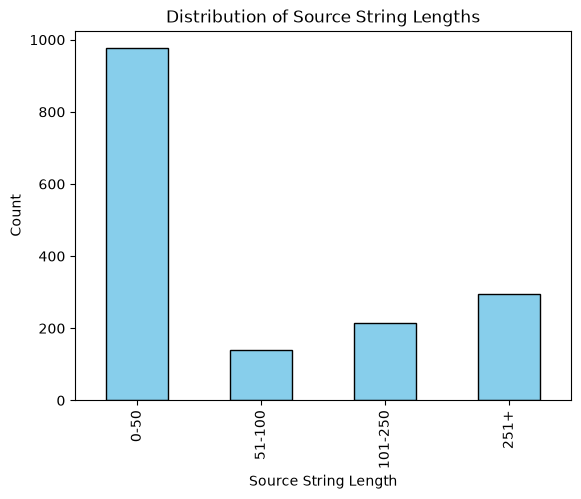

In [37]:
histogram_source = source_length_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Source String Lengths")
plt.xlabel("Source String Length")
plt.ylabel("Count")
plt.show()

In [36]:
# Distribution of target string lengths
translation_memory_df["target_length"] = translation_memory_df["target"].apply(len)
bins = [0, 50, 100, 250, np.inf]
labels = ["0-50", "51-100", "101-250", "251+"]

translation_memory_df["target_length_category"] = pd.cut(translation_memory_df["target_length"], 
                                                         bins=bins, 
                                                         labels=labels, 
                                                         right=False)
target_length_distribution = translation_memory_df["target_length_category"].value_counts().sort_index()
print("Distribution of target string lengths:")
print(target_length_distribution)

Distribution of target string lengths:
target_length_category
0-50       977
51-100     127
101-250    197
251+       323
Name: count, dtype: int64


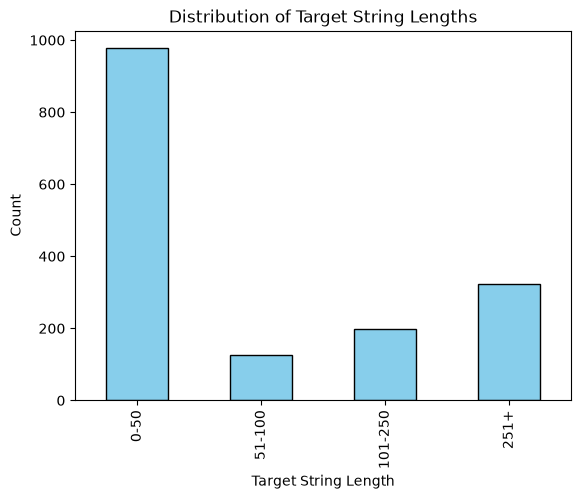

In [38]:
histogram_target = target_length_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Target String Lengths")
plt.xlabel("Target String Length")
plt.ylabel("Count")
plt.show()

In [23]:
# Counting records with variables
records_with_variables = translation_memory_df[translation_memory_df["source"].str.contains(r"\$\w+")]
print(f"Records with variables: {len(records_with_variables)}")

Records with variables: 11
